# Evaluation Metrics (Classification)

After training a classification model, we need to answer one question:

> **How well is the model making predictions?**

Evaluation metrics measure the model's performance by comparing its **predicted labels** with the **actual labels**.

For classification problems, the foundation of almost every evaluation metric is the **Confusion Matrix**.

---

# Confusion Matrix

A **Confusion Matrix** is a table that summarizes how many predictions were correct and how many were incorrect.

For **binary classification**, it is a **2 × 2 matrix**.

```
                 Predicted
               0          1
Actual 0      TN         FP
Actual 1      FN         TP
```

* Rows → Actual values
* Columns → Predicted values

---

# 1. True Positive (TP)

The model predicts **Positive**, and the actual class is also **Positive**.

The prediction is **correct**.

### Example

A patient actually has cancer, and the model predicts cancer.

```
Actual    = 1
Predicted = 1
```

---

# 2. True Negative (TN)

The model predicts **Negative**, and the actual class is also **Negative**.

The prediction is **correct**.

### Example

A healthy patient is predicted as healthy.

```
Actual    = 0
Predicted = 0
```

---

# 3. False Positive (FP)

The model predicts **Positive**, but the actual class is **Negative**.

The prediction is **incorrect**.

Also called:

`Type I Error`

### Example

A plagiarism detector flags an original assignment as plagiarized.

```
Actual    = 0
Predicted = 1
```

The model raises a false alarm.

---

# 4. False Negative (FN)

The model predicts **Negative**, but the actual class is **Positive**.

The prediction is **incorrect**.

Also called:

`Type II Error`

### Example

A defective product passes quality inspection.

```
Actual    = 1
Predicted = 0
```

The model misses the actual positive case.

---

# Intuition

Think of a security guard.

* **TP:** Stops an actual thief.
* **TN:** Lets an innocent person enter.
* **FP:** Stops an innocent person.
* **FN:** Lets a thief go inside.

A good classifier tries to **maximize TP and TN** while **minimizing FP and FN**.

---

# Example Confusion Matrix

```
                 Predicted
               0      1
Actual 0      25      4
Actual 1       3     29
```

Here,

* **TN = 25**
* **FP = 4**
* **FN = 3**
* **TP = 29**

This means:

* 25 negatives were classified correctly.
* 29 positives were classified correctly.
* 4 false alarms were made.
* 3 positive cases were missed.

---

# Accuracy
How often is the model correct.  
Accuracy measures the **overall percentage of correct predictions**.
( TP + TN ) / Total predictions

### Formula

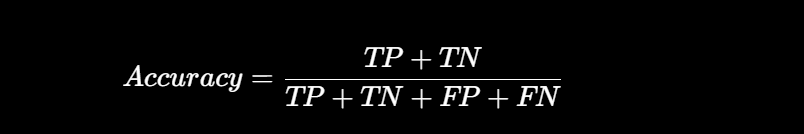

For the example above,

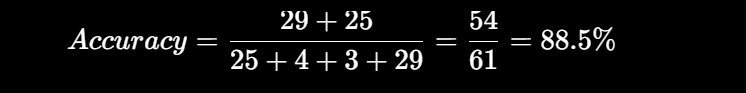

Use Accuracy when  
when datasets are balanced (50/50) and all classes hold equal importance.  
Both False Positives and False Negatives are equally important.  

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
```
---

# Precision

When model predicts positive, how often is it correct.  

Precision answers the question:

> **Out of all the positive predictions, how many were actually positive?**

TP / (TP + FP)
### Formula

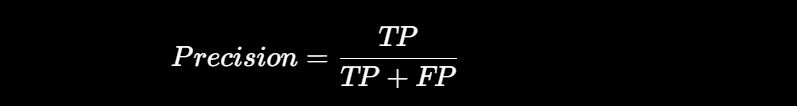

High precision means the model makes **very few false positive predictions**. used for type 1 error.

### Example

Email spam detection.

If an important email is marked as spam, that is a False Positive. High precision minimizes such mistakes.

```python
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)
```

Use Precision when:  

False Positives are costly (`Type I Error`).  

---

# Recall (Sensitivity)

Recall answers the question:

> **Out of all actual positive cases, how many did the model correctly find?**

### Formula

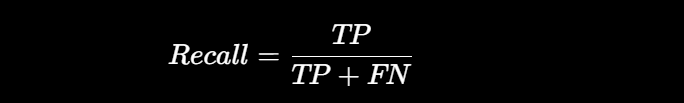

High recall means the model misses **very few positive cases**.

### Example

Cancer detection.

Missing a cancer patient (False Negative) is dangerous, so high recall is more important than precision.

```python
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)
```
Use Recall when:  

False Negatives are costly (`Type II Error`).  

---

# F1 Score

Sometimes we need both high precision and high recall.

The **F1 Score** combines both into a single metric using their harmonic mean.

### Formula

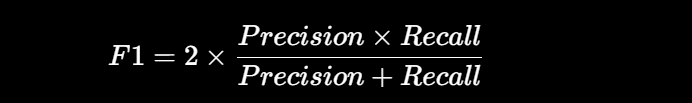

A high F1 score means the model has a good balance between precision and recall.

```python
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
```
Use F1 Score when:  
Dataset is imbalanced.  
Precision and Recall are equally important.  
You need a balance between precision and recall.

---

# Support

Support is simply the **number of actual samples belonging to each class**.

It tells you how many examples of each class were present in the test dataset.

It is **not a performance metric**.

---

# `classification_report()`

```python
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
```

This function automatically calculates:

* Precision
* Recall
* F1-score
* Support

for every class, along with overall averages.

---

# `confusion_matrix()`

```python
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
```

This function returns the confusion matrix.

Example output:

```python
[[25  4]
 [ 3 29]]
```

which means

```text
TN = 25
FP = 4
FN = 3
TP = 29
```

---

# When should each metric be prioritized?

| Metric        | Use when...                                                               |
| ------------- | ------------------------------------------------------------------------- |
| **Accuracy**  | Classes are balanced and both error types are equally important.          |
| **Precision** | False Positives are costly. Type 1 error (e.g., spam detection, plagiarism detection).  |
| **Recall**    | False Negatives are costly. Type 2 error (e.g., disease detection, fraud detection).    |
| **F1 Score**  | Both Precision and Recall are important, especially with imbalanced data. |

---

## Final intuition

The **Confusion Matrix** is the foundation of classification evaluation. It tells you exactly **where the model is making mistakes**. Metrics like **Accuracy, Precision, Recall, and F1-score** are simply different ways of summarizing the information inside that matrix, each emphasizing a different aspect of the model's performance.
